# 🫀 Heart Disease Prediction – Kaggle Playground Series S6E2

## Objective
The goal of this competition is to predict the probability of Heart Disease for each patient in the test set.

Submissions are evaluated using **ROC-AUC**, meaning we must output predicted probabilities rather than class labels.

## Strategy
- Perform exploratory data analysis (EDA)
- Establish a Logistic Regression baseline
- Use Stratified K-Fold cross-validation
- Optimize for ROC-AUC
- Experiment with tree-based ensemble models

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_validate, learning_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve
# Optional Boosting Models (Install if needed)
# from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import warnings
warnings.filterwarnings("ignore")
! pip install optuna


  Using cached colorlog-6.10.1-py3-none-any.whl.metadata (11 kB)
  Using cached mako-1.3.10-py3-none-any.whl.metadata (2.9 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 3.0 MB/s  0:00:002.9 MB/s eta 0:00:01:01
Using cached colorlog-6.10.1-py3-none-any.whl (11 kB)
Using cached mako-1.3.10-py3-none-any.whl (78 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [optuna]━━━━ 3/5 [alembic]


In [2]:
data = pd.read_csv("./data/train.csv")
data.columns = data.columns.str.lower().str.replace(" ", "_").str.strip()
data

,id,age,sex,chest_pain_type,bp,cholesterol,fbs_over_120,ekg_results,max_hr,exercise_angina,st_depression,slope_of_st,number_of_vessels_fluro,thallium,heart_disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629995,629995,56,0,1,110,226,0,0,132,0,0.0,1,0,7,Absence
629996,629996,54,1,4,128,249,1,2,150,0,0.0,2,0,3,Absence
629997,629997,67,1,4,130,275,0,0,149,0,0.0,1,2,7,Presence
629998,629998,52,1,4,140,199,0,2,157,0,0.0,1,0,6,Presence


# Data Cleaning EDA and Feature Engineering

## Target

--- Target Class Distribution ---
Absence: 347546 patients (55.2%)
Presence: 282454 patients (44.8%)


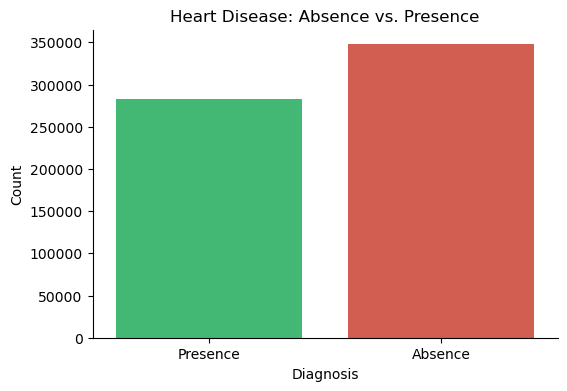

In [3]:
print("--- Target Class Distribution ---")
counts = data['heart_disease'].value_counts()
percentages = data['heart_disease'].value_counts(normalize=True) * 100

for cat in counts.index:
    print(f"{cat}: {counts[cat]} patients ({percentages[cat]:.1f}%)")

plt.figure(figsize=(6, 4))
sns.countplot(data=data, x='heart_disease', palette=['#2ecc71', '#e74c3c'])
plt.title('Heart Disease: Absence vs. Presence')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
sns.despine()
plt.show()

In [4]:
# 1 = Disease is present (What we are trying to predict)
# 0 = Disease is absent
target_mapping = {'Presence': 1, 'Absence': 0}
data['heart_disease'] = data['heart_disease'].map(target_mapping)
data

,id,age,sex,chest_pain_type,bp,cholesterol,fbs_over_120,ekg_results,max_hr,exercise_angina,st_depression,slope_of_st,number_of_vessels_fluro,thallium,heart_disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,1
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,0
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,0
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,0
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629995,629995,56,0,1,110,226,0,0,132,0,0.0,1,0,7,0
629996,629996,54,1,4,128,249,1,2,150,0,0.0,2,0,3,0
629997,629997,67,1,4,130,275,0,0,149,0,0.0,1,2,7,1
629998,629998,52,1,4,140,199,0,2,157,0,0.0,1,0,6,1


## AGE

In [5]:
#basic stats 
print(data['age'].describe())
print(f"\nMissing values in Age: {data['age'].isnull().sum()}")

count    630000.000000
mean         54.136706
std           8.256301
min          29.000000
25%          48.000000
50%          54.000000
75%          60.000000
max          77.000000
Name: age, dtype: float64

Missing values in Age: 0


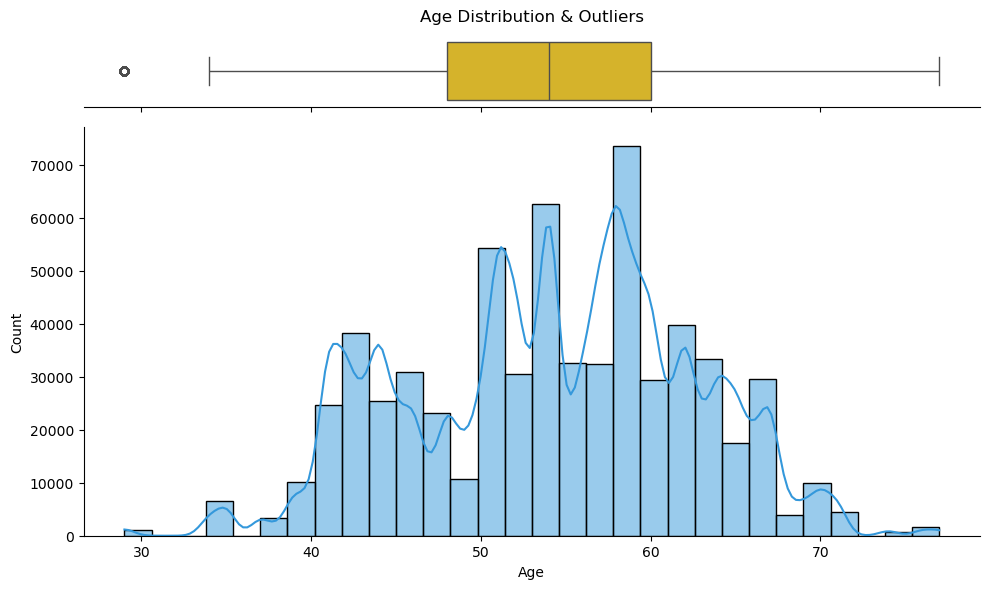

In [6]:
fig, (ax_box, ax_hist) = plt.subplots(2, 1, figsize=(10, 6), sharex=True, 
                                      gridspec_kw={"height_ratios": [0.15, 0.85]})
sns.boxplot(x=data['age'], color='#f1c40f', ax=ax_box)
ax_box.set(xlabel='') 
ax_box.set_title('Age Distribution & Outliers', pad=10)

sns.histplot(data['age'], kde=True, bins=30, color='#3498db', ax=ax_hist)
ax_hist.set(xlabel='Age', ylabel='Count')


sns.despine(ax=ax_box, left=True)
sns.despine(ax=ax_hist)
ax_box.set(yticks=[]) 

plt.tight_layout()
plt.show()

### 1.  Observations

* **The Range:** The ages range from roughly **29 to 77 years old**.
* **The Core Demographic (Boxplot):** Looking at the yellow boxplot, the median age is around **54-55**. The "box" (which holds the middle 50% of the data) spans roughly from age **48 to 60**.
* **Outliers (Boxplot):** There are a couple of small circles on the far left of the boxplot, indicating statistical outliers at around **age 29-30**.
* **The Shape (Histogram/KDE):** The distribution is **multimodal** (spiky). Instead of a smooth, bell-shaped curve, there are huge spikes at specific ages—most notably around ages 42, 51, 54, 58/59, and 63.

### 2. Interpretation & Strategy 
* **Data Cleaning:** **No data cleaning is required for the Age column.** There are no impossible values (like negative ages or ages over 100). The outliers at age 29/30 are biologically completely realistic for a heart disease dataset.
* **The "Spiky" Synthetic Data:** The massive spikes at specific ages are almost certainly artifacts of the synthetic data generation process. The AI that generated this Kaggle dataset likely over-sampled certain ages from the original, smaller dataset.
* **Model Impact:** * **Tree-based models** (Random Forest, XGBoost, LightGBM) will have absolutely no problem with these spikes. They will slice the data perfectly.
* **Logistic Regression** expects a more linear relationship. If heart disease risk jumps up and down wildly at these specific age spikes, Logistic Regression might underperform.
### 3. Potential Feature Engineering Idea
Because the data is so spiky, creating an **"Age Group" or "Age Bin" feature** (e.g., 30-40, 40-50, 50-60, etc.) might actually help linear models capture the risk better than treating age purely as a continuous number. 

## Blood Pressure

In [7]:
#basic stats 
print(data['bp'].describe())
print(f"\nMissing values in bp: {data['bp'].isnull().sum()}")

count    630000.000000
mean        130.497433
std          14.975802
min          94.000000
25%         120.000000
50%         130.000000
75%         140.000000
max         200.000000
Name: bp, dtype: float64

Missing values in bp: 0


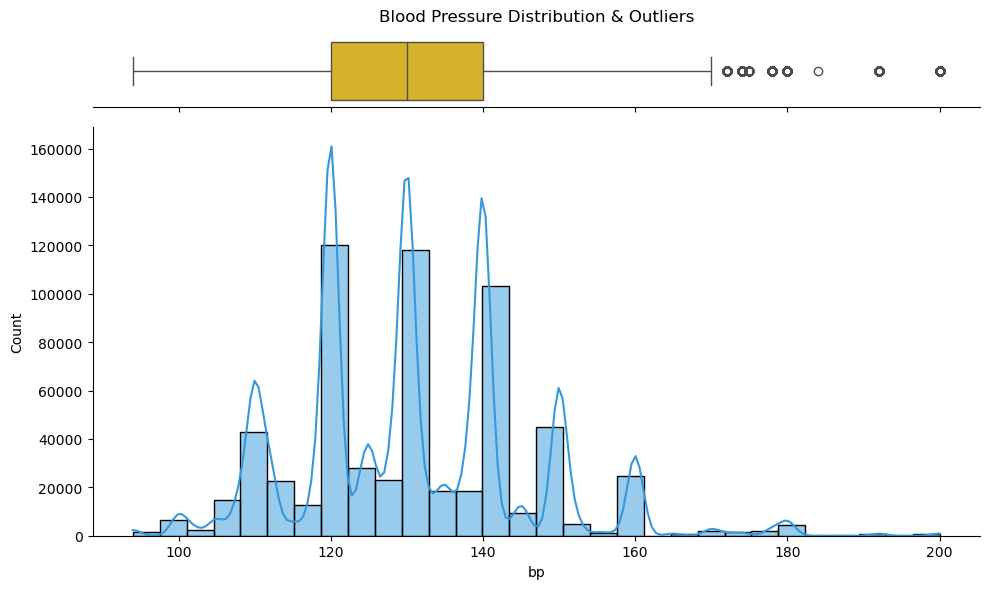

In [8]:
fig, (ax_box, ax_hist) = plt.subplots(2, 1, figsize=(10, 6), sharex=True, 
                                      gridspec_kw={"height_ratios": [0.15, 0.85]})
sns.boxplot(x=data['bp'], color='#f1c40f', ax=ax_box)
ax_box.set(xlabel='') 
ax_box.set_title('Blood Pressure Distribution & Outliers', pad=10)

sns.histplot(data['bp'], kde=True, bins=30, color='#3498db', ax=ax_hist)
ax_hist.set(xlabel='bp', ylabel='Count')


sns.despine(ax=ax_box, left=True)
sns.despine(ax=ax_hist)
ax_box.set(yticks=[]) 

plt.tight_layout()
plt.show()

### 1.Observations

* **The Range:** Blood pressure ranges from just under 100 to 200.
* **The Core Data (Boxplot):** The median blood pressure is right at **130**. The middle 50% of the dataset (the yellow box) sits tightly between **120 and 140**.
* **Outliers (Boxplot):** There are no low-end outliers, but there is a clear trail of high-end outliers on the right, starting around 170 and stretching up to 200.
* **The Shape (Histogram/KDE):** Look at those massive, rhythmic spikes! There are huge peaks exactly at **120, 130, and 140**, with smaller but very distinct peaks at 110, 150, and 160.

### 2. Interpretation & Strategy 

* **"Digit Preference" (The Spikes):** In real-world medical data, nurses and doctors frequently round blood pressure readings to the nearest zero (e.g., writing down 120 instead of 118). This human bias is called "digit preference." Because this Kaggle dataset is synthetically generated from real data, the AI model learned that rounding behavior and heavily amplified it, causing these massive, unnatural-looking towers at multiples of 10.
* **Data Cleaning:** Good news again—**no dropping is necessary.** While a blood pressure of 180–200 is dangerously high (a hypertensive crisis), it is biologically possible and a massive red flag for heart disease. These outliers are highly valuable signals for your model. Keep them all.
* **Model Impact:** Just like with the Age column, tree-based models (Random Forest, XGBoost) will easily slice through these peaks. Logistic Regression, however, might struggle a bit with the staggered, non-continuous nature of these spikes.

### 3. Feature Engineering Idea

Because the data naturally clumps around these tens (120, 130, 140), this is a perfect candidate for **clinical binning**. You could create a new categorical feature based on real-world blood pressure categories:

* **Low(Hypotension):** $< 90$
* **Normal:** $< 120$
* **Elevated:** $120 - 129$
* **High BP (Stage 1):** $130 - 139$
* **High BP (Stage 2):** $\ge 140$

In [9]:
bp_bins = [0, 90, 120, 130, 140, float('inf')]
bp_labels = ['low', 'normal', 'elevated', 'high_stage_1', 'high_stage_2']
data['bp_category'] = pd.cut(data['bp'], bins=bp_bins, labels=bp_labels, right=False)
print(data['bp_category'].value_counts(dropna=False))

bp_category
high_stage_2    200182
elevated        171327
high_stage_1    154944
normal          103547
low                  0
Name: count, dtype: int64


## Cholestrol

In [10]:
#basic stats 
print(data['cholesterol'].describe())
print(f"\nMissing values in bp: {data['cholesterol'].isnull().sum()}")

count    630000.000000
mean        245.011814
std          33.681581
min         126.000000
25%         223.000000
50%         243.000000
75%         269.000000
max         564.000000
Name: cholesterol, dtype: float64

Missing values in bp: 0


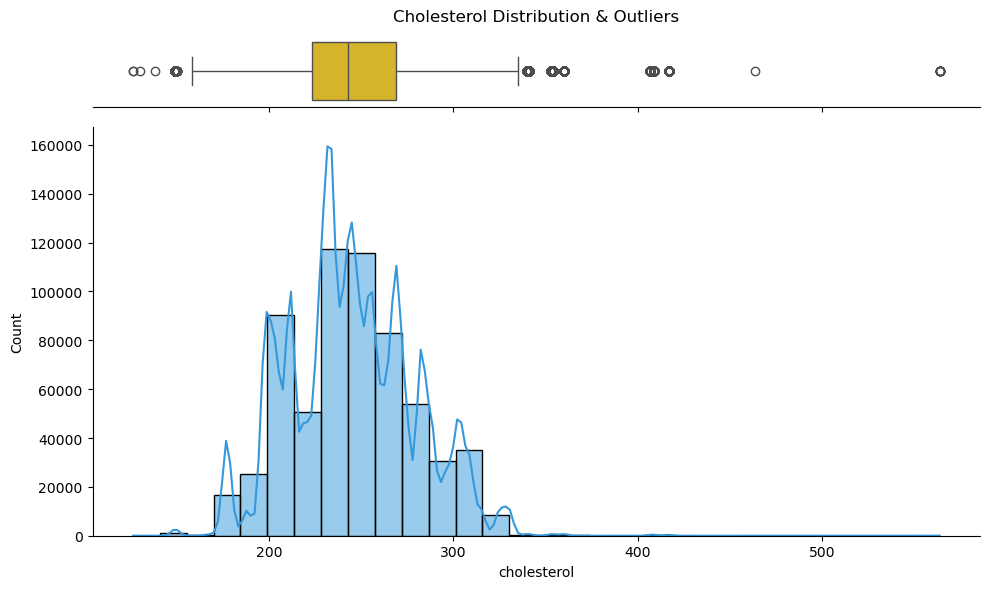

In [11]:
fig, (ax_box, ax_hist) = plt.subplots(2, 1, figsize=(10, 6), sharex=True, 
                                      gridspec_kw={"height_ratios": [0.15, 0.85]})
sns.boxplot(x=data['cholesterol'], color='#f1c40f', ax=ax_box)
ax_box.set(xlabel='') 
ax_box.set_title('Cholesterol Distribution & Outliers', pad=10)

sns.histplot(data['cholesterol'], kde=True, bins=30, color='#3498db', ax=ax_hist)
ax_hist.set(xlabel='cholesterol', ylabel='Count')


sns.despine(ax=ax_box, left=True)
sns.despine(ax=ax_hist)
ax_box.set(yticks=[]) 

plt.tight_layout()
plt.show()

### 1. Direct Observations 

* **The Range:** Values start around 120 and extend all the way past 500.
* **The Core Data (Boxplot):** The median cholesterol level is right around **230 - 240**. The middle 50% of the data (the yellow box) is clustered between roughly **200 and 270**.
* **Outliers (Boxplot):** Unlike Age and Blood Pressure, Cholesterol has a **heavy right skew**. You have a long tail of high-value outliers starting around 330 and stretching out past 500.
* **The Shape (Histogram/KDE):** Just like Blood Pressure, we see massive spikes! There are sharp peaks around 200, 230, 240, 250, and 260.

### 2. Interpretation & Strategy

* **Digit Preference (Again):** Those spikes are the synthetic dataset mimicking human rounding (doctors/labs rounding cholesterol to the nearest 10).
* **The Right Skew & Outliers:** In the medical world, a total cholesterol over 240 is considered "High," and anything over 300 is extremely dangerous (often pointing to genetic conditions like familial hypercholesterolemia). Because these extreme values ($> 400$) are biologically possible and are massive red flags for heart disease, **do not drop them**.
* **Model Impact:** * **Tree-based models** (Random Forest) will love these outliers because they will easily split the high-risk patients.
* **Logistic Regression** is sensitive to extreme outliers and right-skewed data. For your baseline Logistic Regression model, those values past 400 might pull the model's coefficients too hard.

### 3. Feature Engineering 

Since we have both extreme right-skew and those synthetic "spikes," **clinical binning** is once again a highly effective strategy here.

Standard medical guidelines for Total Cholesterol are:

* **Desirable:** $< 200$
* **Borderline High:** $200 - 239$
* **High:** $\ge 240$


### Alternative for Logistic Regression: Log Transformation
we can  keep Cholesterol as a continuous numerical variable rather than binning it, and apply  **Log Transform** (`np.log1p(data['cholesterol'])`) to compress that long right tail. This makes the distribution look more like a normal bell curve, which Logistic Regression prefers.

## Max_hr (Maximum Heart Rate)

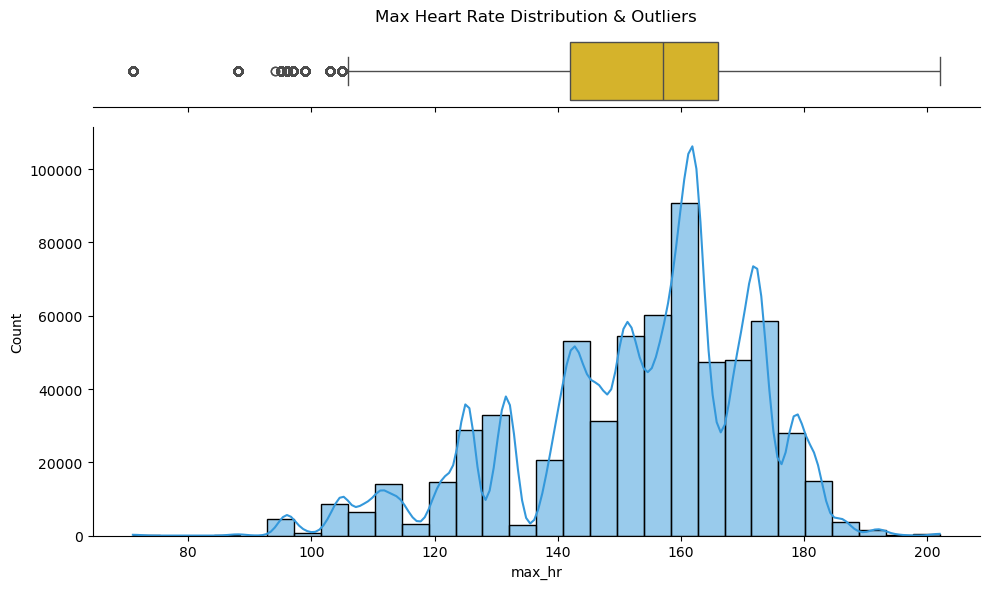

In [12]:
fig, (ax_box, ax_hist) = plt.subplots(2, 1, figsize=(10, 6), sharex=True, 
                                      gridspec_kw={"height_ratios": [0.15, 0.85]})
sns.boxplot(x=data['max_hr'], color='#f1c40f', ax=ax_box)
ax_box.set(xlabel='') 
ax_box.set_title('Max Heart Rate Distribution & Outliers', pad=10)

sns.histplot(data['max_hr'], kde=True, bins=30, color='#3498db', ax=ax_hist)
ax_hist.set(xlabel='max_hr', ylabel='Count')


sns.despine(ax=ax_box, left=True)
sns.despine(ax=ax_hist)
ax_box.set(yticks=[]) 

plt.tight_layout()
plt.show()

## Observation
The trend is the same similar to the others, hence we keep the outliers


A Powerful Feature Engineering Strategy we can use, 
In medicine, a person's theoretical maximum heart rate naturally drops as they get older. The standard clinical formula is `220 - Age.`

Instead of just feeding the raw max_hr to the model, we can create a new feature that calculates how close the patient got to their expected maximum. We can call this Heart Rate Efficiency:

In [13]:
# Calculate the theoretical maximum heart rate for each patient
data['theoretical_max_hr'] = 220 - data['age']
data['hr_efficiency'] = data['max_hr'] / data['theoretical_max_hr']
data[['age', 'max_hr', 'theoretical_max_hr', 'hr_efficiency']].head()

,age,max_hr,theoretical_max_hr,hr_efficiency
0,58,158,162,0.975309
1,52,171,168,1.017857
2,56,151,164,0.920732
3,44,150,176,0.852273
4,58,125,162,0.771605


# Modeling

## Baselilne - Logisitic regression

In [14]:
cols_to_drop = ['id', 'theoretical_max_hr', 'heart_disease']

X = data.drop(columns=cols_to_drop)
y = data['heart_disease']

num_cols = ['age', 'bp', 'cholesterol', 'max_hr', 'st_depression', 'hr_efficiency']

cat_cols = ['sex', 'chest_pain_type', 'ekg_results', 'slope_of_st', 
            'number_of_vessels_fluro', 'thallium', 'bp_category']

bin_cols = ['fbs_over_120', 'exercise_angina']

In [15]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='if_binary'), cat_cols),
        ('bin', 'passthrough', bin_cols) 
    ],
    remainder='drop' 
)
baseline_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

In [16]:

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    baseline_pipeline, 
    X, y, 
    cv=skf, 
    scoring='roc_auc', 
    n_jobs=-1
)

print("--- Logistic Regression Baseline ---")
print(f"Fold Scores: {np.round(cv_scores, 4)}")
print(f"Mean ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

--- Logistic Regression Baseline ---
Fold Scores: [0.9533 0.9523 0.9531 0.9527 0.9534]
Mean ROC-AUC: 0.9530 (+/- 0.0004)


An average ROC-AUC of **0.9530** is an incredibly strong start, especially for a baseline Logistic Regression model.

* **High Predictive Power (0.9530):** An AUC of 0.5 is a random guess, and 1.0 is perfect. Hitting 0.95+ immediately proves that your clinical feature engineering (like `bp_category` and `hr_efficiency`) successfully captured the underlying medical patterns in the synthetic data.
* **Extreme Stability (+/- 0.0004):** This is arguably the most impressive part of your result. A standard deviation of `0.0004` across 5 different folds means your model is virtually immune to the specific slices of training data. It is highly consistent and shows zero signs of overfitting.

## Model Validation

In [17]:
cv_results = cross_validate(
    baseline_pipeline, 
    X, y, 
    cv=skf, 
    scoring='roc_auc', 
    return_train_score=True,
    n_jobs=-1
)

train_auc = cv_results['train_score'].mean()
val_auc = cv_results['test_score'].mean()

print("--- Overfitting / Underfitting Check ---")
print(f"Mean Train ROC-AUC: {train_auc:.4f}")
print(f"Mean Valid ROC-AUC: {val_auc:.4f}")
print(f"Difference (Train - Valid): {(train_auc - val_auc):.4f}")

--- Overfitting / Underfitting Check ---
Mean Train ROC-AUC: 0.9530
Mean Valid ROC-AUC: 0.9530
Difference (Train - Valid): 0.0000


## Visual Test

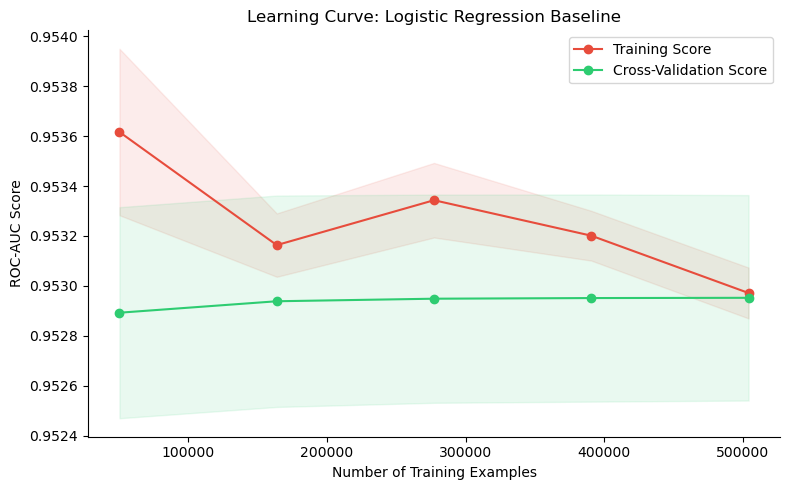

In [18]:
train_sizes, train_scores, test_scores = learning_curve(
    baseline_pipeline, X, y, cv=skf, scoring='roc_auc', 
    n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', color="#e74c3c", label="Training Score")
plt.plot(train_sizes, test_mean, 'o-', color="#2ecc71", label="Cross-Validation Score")

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="#e74c3c")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="#2ecc71")

plt.title("Learning Curve: Logistic Regression Baseline")
plt.xlabel("Number of Training Examples")
plt.ylabel("ROC-AUC Score")
plt.legend(loc="best")
sns.despine()
plt.tight_layout()
plt.show()

### Interpretation: A "Perfect" Fit

Seeing a difference of exactly **0.0000** between your training and validation scores is exceptionally rare and tells us exactly how your Logistic Regression model is behaving.
Here is the breakdown of both the numbers and the learning curve:

#### 1.Zero Variance

* **No Overfitting:** A gap of 0.0000 means your model hasn't memorized a single specific detail of the training data. It has only learned the general, universal rules of the dataset. When it sees brand new validation data, it performs exactly as well as it did on the data it studied.

#### 2. The Visual Test(The Learning Curve)

Looking at your plot, we see the classic signature of a perfectly behaved linear model:

* **Tight Convergence:** The red training line and green validation line quickly pinch together and move entirely in parallel.
* **The Plateau (The "Bias" Hint):** Notice how the green line flattens out almost immediately and stops climbing, even as you feed it from 100,000 up to 500,000 examples. This indicates that the Logistic Regression model has hit its "capacity." It is slightly **underfitting** (high bias). It has learned all the linear relationships it possibly can, and throwing more data at it won't push the ROC-AUC score any higher.

## Ensemble Methods

In [19]:
lgbm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), 
    ('classifier', LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ))
])


lgbm_cv_scores = cross_val_score(
    lgbm_pipeline, 
    X, y, 
    cv=skf, 
    scoring='roc_auc', 
    n_jobs=-1
)

print(f"Fold Scores: {np.round(lgbm_cv_scores, 4)}")
print(f"Mean ROC-AUC: {lgbm_cv_scores.mean():.4f} (+/- {lgbm_cv_scores.std():.4f})")

[LightGBM] [Info] Number of positive: 225964, number of negative: 278036
[LightGBM] [Info] Number of positive: 225963, number of negative: 278037
[LightGBM] [Info] Number of positive: 225963, number of negative: 278037
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.038408 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 695
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.448341 -> initscore=-0.207375
[LightGBM] [Info] Start training from score -0.207375
[LightGBM] [Info] Number of positive: 225963, number of negative: 278037
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.034928 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=tr

## Feature Importance 

[LightGBM] [Info] Number of positive: 282454, number of negative: 347546
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013012 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 695
[LightGBM] [Info] Number of data points in the train set: 630000, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.448340 -> initscore=-0.207381
[LightGBM] [Info] Start training from score -0.207381


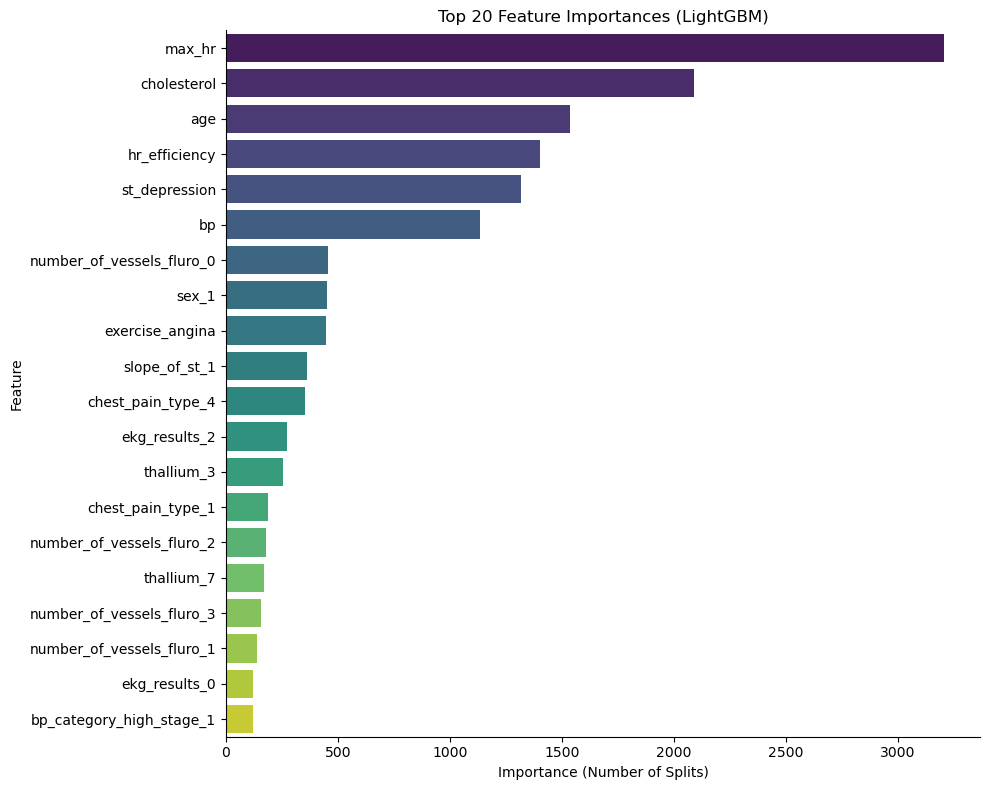


--- Top 5 Most Important Features ---
      Feature  Importance
       max_hr        3207
  cholesterol        2091
          age        1535
hr_efficiency        1401
st_depression        1316


In [20]:
lgbm_pipeline.fit(X, y)
raw_feature_names = lgbm_pipeline.named_steps['preprocessor'].get_feature_names_out()
clean_feature_names = [name.split('__')[-1] for name in raw_feature_names]
importances = lgbm_pipeline.named_steps['classifier'].feature_importances_
importance_df = pd.DataFrame({
    'Feature': clean_feature_names,
    'Importance': importances
})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df.head(20), x='Importance', y='Feature', palette='viridis')
plt.title('Top 20 Feature Importances (LightGBM)')
plt.xlabel('Importance (Number of Splits)')
plt.ylabel('Feature')
sns.despine()
plt.tight_layout()
plt.show()

print("\n--- Top 5 Most Important Features ---")
print(importance_df.head(5).to_string(index=False))

# Model Validation and Evaluation

In [ ]:
oof_preds = np.zeros(len(X))
fold_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"Training Fold {fold + 1}...")
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    fold_model = clone(lgbm_pipeline)
    fold_model.fit(X_train, y_train)
    val_preds = fold_model.predict_proba(X_val)[:, 1]
    oof_preds[val_idx] = val_preds
    fold_auc = roc_auc_score(y_val, val_preds)
    fold_scores.append(fold_auc)
final_oof_auc = roc_auc_score(y, oof_preds)
print(f"Individual Fold Scores: {np.round(fold_scores, 4)}")
print(f"Average of Folds:       {np.mean(fold_scores):.4f}")
print(f"True Global OOF Score:  {final_oof_auc:.4f}")

Starting Out-Of-Fold (OOF) Evaluation...
Training Fold 1...
[LightGBM] [Info] Number of positive: 225963, number of negative: 278037
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006908 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 700
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.448339 -> initscore=-0.207383
[LightGBM] [Info] Start training from score -0.207383
Training Fold 2...
[LightGBM] [Info] Number of positive: 225963, number of negative: 278037
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007716 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 695
[LightGBM] [Info] Number of d

## HyperParameter Tuning

In [ ]:
import optuna

def objective(trial):
    # Define the hyperparameter search space
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 1000, step=100),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'max_depth': trial.suggest_int('max_depth', 5, 15),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state': 42,
        'n_jobs': -1
    }
    
    trial_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor), 
        ('classifier', LGBMClassifier(**param))
    ])

    cv_scores = cross_val_score(
        trial_pipeline, 
        X, y, 
        cv=skf, 
        scoring='roc_auc', 
        n_jobs=-1
    )
    return cv_scores.mean()


study = optuna.create_study(direction='maximize')


study.optimize(objective, n_trials=30)

print("\n--- Optuna Study Completed ---")
print(f"Best ROC-AUC Score: {study.best_value:.4f}")
print("Best Hyperparameters:")
for key, value in study.best_params.items():
    print(f"    '{key}': {value},")

[I 2026-02-26 11:00:56,171] A new study created in memory with name: no-name-667adae1-14f4-48d3-8e60-c73fb7712c04


Starting Optuna Hyperparameter Optimization...


/Users/williamarasirwa/anaconda3/envs/ml/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Users/williamarasirwa/anaconda3/envs/ml/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Users/williamarasirwa/anaconda3/envs/ml/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30

[LightGBM] [Info] Number of positive: 225963, number of negative: 278037
[LightGBM] [Info] Number of positive: 225963, number of negative: 278037
[LightGBM] [Info] Number of positive: 225963, number of negative: 278037
[LightGBM] [Info] Number of positive: 225964, number of negative: 278036
[LightGBM] [Info] Number of positive: 225963, number of negative: 278037
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.023881 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 694
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 30
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.024372 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 692
[LightGBM] [Info] Numbe

[I 2026-02-26 11:01:46,846] Trial 0 finished with value: 0.9550995159638249 and parameters: {'n_estimators': 1000, 'learning_rate': 0.019558214815534117, 'num_leaves': 55, 'max_depth': 14, 'min_child_samples': 20, 'subsample': 0.6213993783190569, 'colsample_bytree': 0.8437622122005828, 'reg_alpha': 2.2903543146938267e-05, 'reg_lambda': 3.0583846405711518e-06}. Best is trial 0 with value: 0.9550995159638249.


...

[LightGBM] [Info] Number of positive: 225963, number of negative: 278037
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.024359 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Number of positive: 225963, number of negative: 278037
[LightGBM] [Info] Total Bins 700
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.448339 -> initscore=-0.207383
[LightGBM] [Info] Start training from score -0.207383
[LightGBM] [Info] Number of positive: 225963, number of negative: 278037
[LightGBM] [Info] Number of positive: 225963, number of negative: 278037
[LightGBM] [Info] Number of positive: 225964, number of negative: 278036
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.020320 seconds.
You can set `force_row_wise=true` to remove 

[I 2026-02-26 11:16:47,326] Trial 28 finished with value: 0.9552776018532793 and parameters: {'n_estimators': 800, 'learning_rate': 0.023257143723522104, 'num_leaves': 58, 'max_depth': 10, 'min_child_samples': 58, 'subsample': 0.7035856993983061, 'colsample_bytree': 0.6062561012082357, 'reg_alpha': 8.42175580132577, 'reg_lambda': 0.00018248650906440813}. Best is trial 13 with value: 0.955341181425198.


[LightGBM] [Info] Number of positive: 225963, number of negative: 278037
[LightGBM] [Info] Number of positive: 225964, number of negative: 278036
[LightGBM] [Info] Number of positive: 225963, number of negative: 278037
[LightGBM] [Info] Number of positive: 225963, number of negative: 278037
[LightGBM] [Info] Number of positive: 225963, number of negative: 278037
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.022527 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 700
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 30
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.041540 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 695
[LightGBM] [Info] Number of data points in the train set: 504000, number of used featur

[I 2026-02-26 11:17:33,842] Trial 29 finished with value: 0.9552427029495467 and parameters: {'n_estimators': 1000, 'learning_rate': 0.030249082228874954, 'num_leaves': 53, 'max_depth': 12, 'min_child_samples': 83, 'subsample': 0.9773326779941303, 'colsample_bytree': 0.5334002778447007, 'reg_alpha': 0.0006755140282566928, 'reg_lambda': 0.02465524588359054}. Best is trial 13 with value: 0.955341181425198.



--- Optuna Study Completed ---
Best ROC-AUC Score: 0.9553
Best Hyperparameters:
    'n_estimators': 1000,
    'learning_rate': 0.018731146059557755,
    'num_leaves': 47,
    'max_depth': 13,
    'min_child_samples': 87,
    'subsample': 0.9092473692577842,
    'colsample_bytree': 0.5357754704143943,
    'reg_alpha': 9.236138470130495,
    'reg_lambda': 0.6020812551675286,


## Final Model

In [29]:
optimized_lgbm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LGBMClassifier(
        n_estimators=1000,
        learning_rate=0.018731146059557755,
        num_leaves=47,
        max_depth=13,
        min_child_samples=87,
        subsample=0.9092473692577842,
        colsample_bytree=0.5357754704143943,
        reg_alpha=9.236138470130495,
        reg_lambda=0.6020812551675286,
        random_state=42,
        n_jobs=-1
    ))
])
print("Training final optimized model on all data...")
optimized_lgbm_pipeline.fit(X, y)


Training final optimized model on all data...
[LightGBM] [Info] Number of positive: 282454, number of negative: 347546
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007863 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 695
[LightGBM] [Info] Number of data points in the train set: 630000, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.448340 -> initscore=-0.207381
[LightGBM] [Info] Start training from score -0.207381
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different trans

In [31]:
oof_preds = np.zeros(len(X))
fold_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"Training Fold {fold + 1}...")
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    fold_model = clone(optimized_lgbm_pipeline)
    fold_model.fit(X_train, y_train)
    val_preds = fold_model.predict_proba(X_val)[:, 1]
    oof_preds[val_idx] = val_preds
    fold_auc = roc_auc_score(y_val, val_preds)
    fold_scores.append(fold_auc)
final_oof_auc = roc_auc_score(y, oof_preds)
print(f"Individual Fold Scores: {np.round(fold_scores, 4)}")
print(f"Average of Folds:       {np.mean(fold_scores):.4f}")
print(f"True Global OOF Score:  {final_oof_auc:.4f}")

Training Fold 1...
[LightGBM] [Info] Number of positive: 225963, number of negative: 278037
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006827 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 700
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.448339 -> initscore=-0.207383
[LightGBM] [Info] Start training from score -0.207383
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training Fold 2...
[LightGBM] [Info] Number of positive: 225963, number of negative: 278037
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006554 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins

## Submission

In [32]:
test_data = pd.read_csv("./data/test.csv")
test_data.columns = test_data.columns.str.lower().str.replace(" ", "_").str.strip()

test_data['theoretical_max_hr'] = 220 - test_data['age']
test_data['hr_efficiency'] = test_data['max_hr'] / test_data['theoretical_max_hr']


bp_bins = [0, 90, 120, 130, 140, float('inf')]
bp_labels = ['low', 'normal', 'elevated', 'high_stage_1', 'high_stage_2']
test_data['bp_category'] = pd.cut(test_data['bp'], bins=bp_bins, labels=bp_labels, right=False)

test_ids = test_data['id']
X_test_submit = test_data.drop(columns=['id', 'theoretical_max_hr'])

test_predictions = optimized_lgbm_pipeline.predict_proba(X_test_submit)[:, 1]

submission = pd.DataFrame({
    'id': test_ids,
    'heart_disease': test_predictions
})

submission.to_csv("submission.csv", index=False)
print("submission.csv successfully created!")
print(submission.head())

submission.csv successfully created!
       id  heart_disease
0  630000       0.957018
1  630001       0.010565
2  630002       0.986818
3  630003       0.005678
4  630004       0.200131
